In [114]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier

In [115]:
df = pd.read_csv("../data/raw/diabetes_130_raw.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [116]:
df.shape
#df.info()
#df.describe()
#print(df.columns)

(101766, 50)

In [117]:
# cleaning dataset
# replace '?' with actual NaN value
df = df.replace("?", np.nan)
df = df.ffill()

In [118]:
# missing values per column
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                       1102
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  20446
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          1
diag_3                          1
number_diagnoses                0
max_glu_serum                 133
A1Cresult                      26
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [119]:
# drop columns with high number of missing values

df = df.drop(columns=['weight','payer_code','medical_specialty'], axis = 1)

In [120]:
# verify that columns are droped or not
df.head(5)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


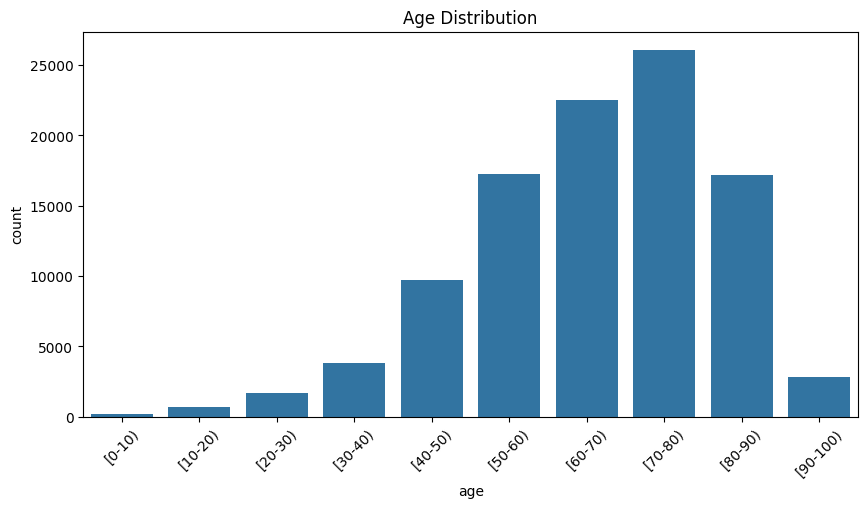

In [121]:
# age distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='age', order=sorted(df['age'].unique()))
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

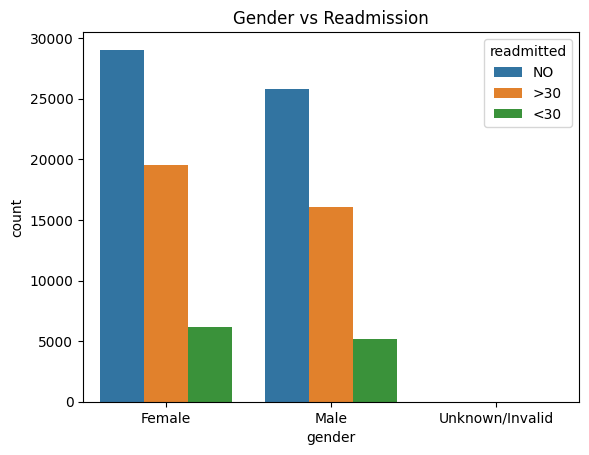

In [122]:
# gender vs readmission
sns.countplot(data=df, x='gender', hue='readmitted')
plt.title("Gender vs Readmission")
plt.show()

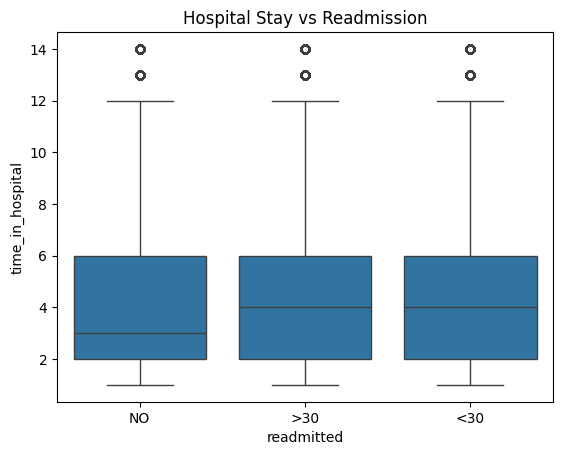

In [123]:
# hospital stay vs readmission
sns.boxplot(data=df, x='readmitted', y='time_in_hospital')
plt.title("Hospital Stay vs Readmission")
plt.show()

In [124]:
# Feature Selection 
df_model = df.copy()

# Dropping IDs (not useful)
df_model.drop(['encounter_id','patient_nbr'], axis=1, inplace=True)

In [125]:
# binary classification
df_model['readmitted'] = df_model['readmitted'].map({
    '<30': 1,
    '>30': 0,
    'NO': 0
})

""" 
<30 → high risk (1)

others → low risk (0) """

' \n<30 → high risk (1)\n\nothers → low risk (0) '

In [126]:
print(df_model['readmitted'].unique())

[0 1]


In [127]:
# ensure numeric
df_model['readmitted'] = df_model['readmitted'].astype(int)

In [128]:
# encoding categorical variables
from sklearn.preprocessing import LabelEncoder
cat_cols = df_model.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [129]:
# train test split
X = df_model.drop('readmitted', axis=1)
y = df_model['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [130]:
# scaling for logistic regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [131]:
# logistic regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.42      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.65      0.50      0.48     20354
weighted avg       0.84      0.89      0.84     20354



In [132]:
# XGBoost

xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.45      0.03      0.05      2285

    accuracy                           0.89     20354
   macro avg       0.67      0.51      0.50     20354
weighted avg       0.84      0.89      0.84     20354



In [137]:
# ROC AUC comparison

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print("Logistic AUC:", lr_auc)
print("XGBoost AUC:", xgb_auc)

Logistic AUC: 0.642291686875487
XGBoost AUC: 0.669766418129967


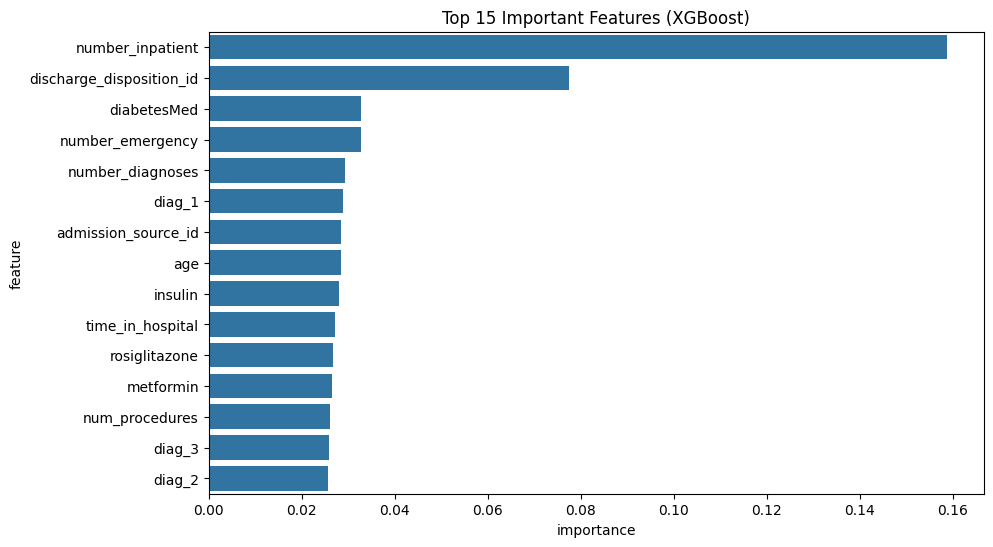

'\nXGBoost identified key features such as number of inpatient visits, time in hospital, and medication changes \nas strong predictors of readmission.\n'

In [145]:

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x='importance', y='feature')
plt.title("Top 15 Important Features (XGBoost)")
plt.show()

"""
XGBoost identified key features such as number of inpatient visits, time in hospital, and medication changes 
as strong predictors of readmission.
"""


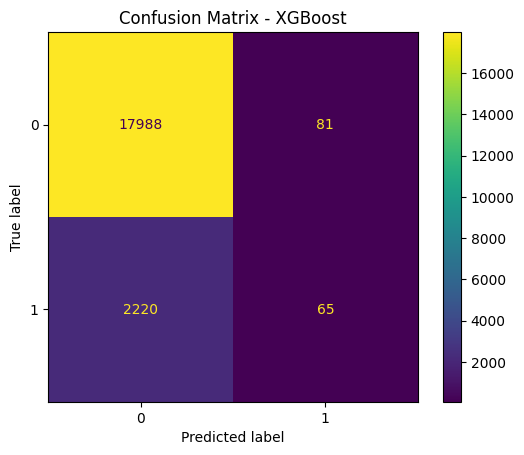

In [144]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [149]:
"""
- Patients with higher inpatient visits and longer hospital stays show higher readmission risk.
- Class imbalance handling improved recall for high-risk patients. """

'\n- Patients with higher inpatient visits and longer hospital stays show higher readmission risk.\n- Class imbalance handling improved recall for high-risk patients. '

In [151]:
# saved cleaned data
df.to_csv("../data/processed/cleaned_data.csv", index=False)